<a href="https://colab.research.google.com/github/Abdul-Rehman-Sayed/python/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1st program
import tensorflow as tf
a = tf.constant(10.0)
b = tf.constant(5.0)
c = tf.constant(3.0)

sub_result = a - b
complex_op_res = (a + b) * (c - 1)

print("Sensor A: ", a.numpy())
print("Sensor B: ", b.numpy())
print("Sensor C: ", c.numpy())
print("a - b:", sub_result.numpy())
print("(a + b) * (c - 1):", complex_op_res.numpy())

Sensor A:  10.0
Sensor B:  5.0
Sensor C:  3.0
a - b:  5.0
(a + b) * (c - 1):  30.0


In [ ]:
# 2nd program
import tensorflow as tf

numbers = tf.range(11, dtype = tf.float32)
squares = tf.square(numbers)

print("Numbers:", numbers.numpy())
print("Squares:", squares.numpy())

Numbers: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Squares: [  0.   1.   4.   9.  16.  25.  36.  49.  64.  81. 100.]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


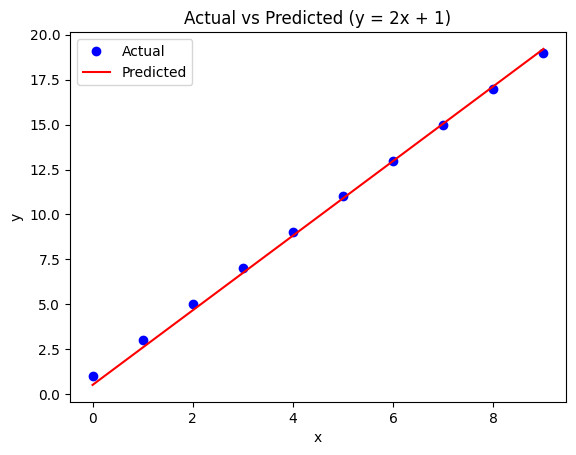

In [ ]:
# 3rd program
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create the dataset
x = np.array(range(10), dtype=float)
y = 2 * x + 1

# Step 2: Build a simple linear model: y = wx + b
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

# Step 3: Compile the model with optimizer and loss function
model.compile(optimizer='sgd', loss='mean_squared_error')

# Step 4: Train the model
model.fit(x, y, epochs=100, verbose=0)

# Step 5: Predict using the trained model
y_pred = model.predict(x)

# Step 6: Plot actual vs predicted
plt.plot(x, y, 'bo', label='Actual')
plt.plot(x, y_pred, 'r-', label='Predicted')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual vs Predicted (y = 2x + 1)")
plt.legend()
plt.show()

In [10]:
import tensorflow as tf, numpy as np

x = np.arange(100).reshape(-1, 1) / 99
y = np.arange(100) % 2

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x, y, epochs=100, batch_size=4, verbose=0)

acc = model.evaluate(x, y, verbose=0)[1]
print(f"\nAccuracy: {acc*100:.2f}%")
p = model.predict(np.array([[45/99]]), verbose=0)[0][0]
print(f"Prediction for 45: {'Odd' if p > 0.5 else 'Even'} ({p*100:.2f}%)")



Accuracy: 51.00%
Prediction for 45: Odd (50.18%)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0   

        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4

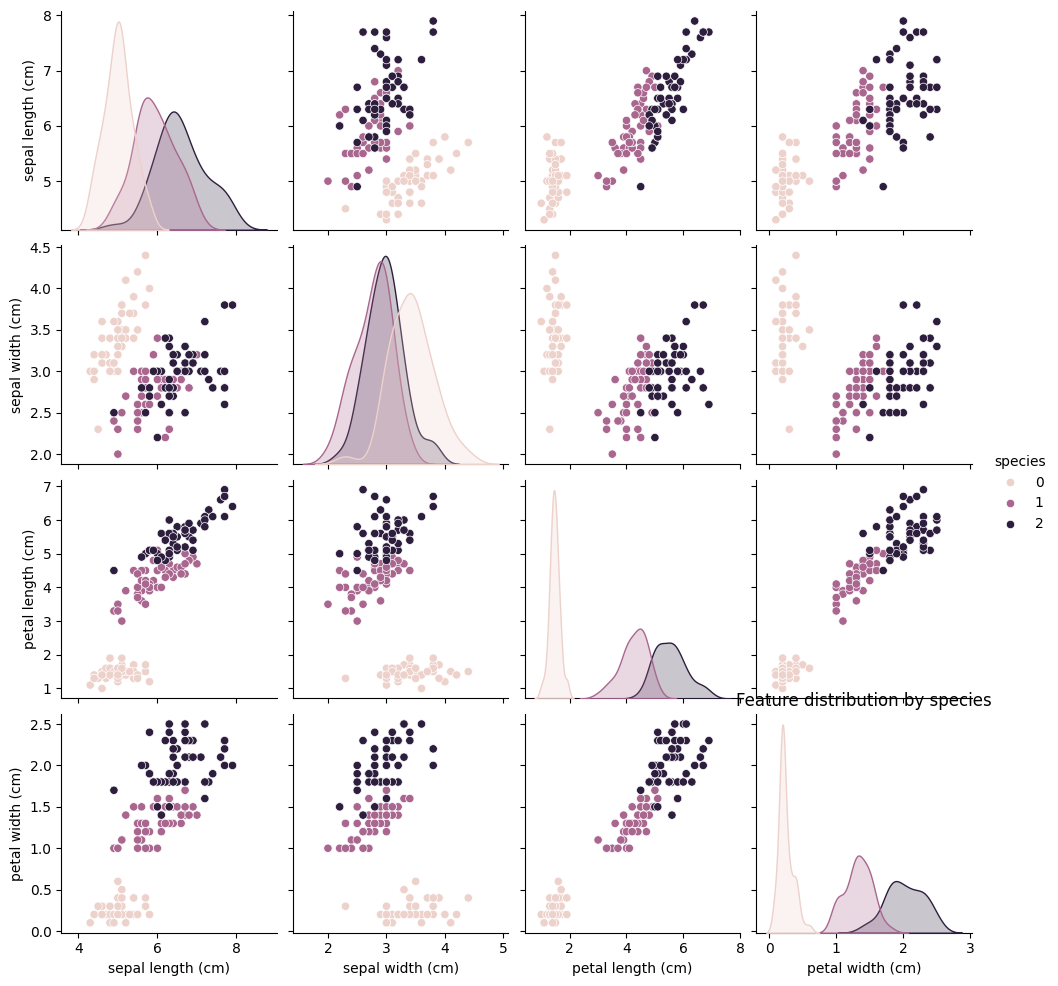

In [ ]:
# 5th program
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

# Basic info
print(df.head(), "\n\n", df.describe())

# Prepare data
x = MinMaxScaler().fit_transform(df.drop('species', axis=1))
y = df['species']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"\nTrain: {len(x_train)}, Test: {len(x_test)}")

# Plotting
sns.pairplot(df, hue='species')
plt.title("Feature distribution by species")
plt.show()

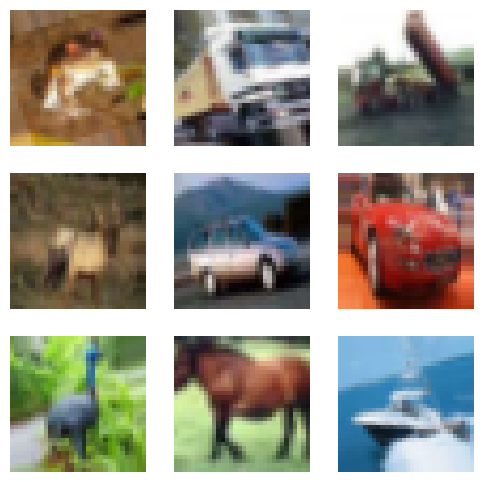

In [8]:
# 6th program
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load and normalize CIFAR-10 data
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0

# Create image augmenter
aug = ImageDataGenerator(rotation_range=20, zoom_range=0.2, horizontal_flip=True)
aug.fit(x_train)

# Display 9 augmented images
for images, _ in aug.flow(x_train, y_train, batch_size=9, shuffle=False):
    plt.figure(figsize=(6,6))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.show()
    break

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load and preprocess
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile & train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate & predict
loss, acc = model.evaluate(x_test, y_test)
print(f"\nLoss: {loss:.4f} | Accuracy: {acc:.4f}")
preds = model.predict(x_test[:5])
for i, p in enumerate(preds):
    print(f"Sample {i+1}: Pred = {p.argmax()}, Actual = {y_test[i].argmax()}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8618 - loss: 0.4673 - val_accuracy: 0.9602 - val_loss: 0.1291
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9658 - loss: 0.1122 - val_accuracy: 0.9725 - val_loss: 0.0922
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9769 - loss: 0.0745 - val_accuracy: 0.9767 - val_loss: 0.0784
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9837 - loss: 0.0508 - val_accuracy: 0.9730 - val_loss: 0.0956
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9860 - loss: 0.0408 - val_accuracy: 0.9788 - val_loss: 0.0893
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9896 - loss: 0.0328 - val_accuracy: 0.9778 - val_loss: 0.0905
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9763 - val_loss: 0.1085
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9931 - loss: 0.021


Loss: 0.0973 | Accuracy: 0.9788
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Sample 1: Pred = 7, Actual = 7
Sample 2: Pred = 2, Actual = 2
Sample 3: Pred = 1, Actual = 1
Sample 4: Pred = 0, Actual = 0
Sample 5: Pred = 4, Actual = 4
